<a href="https://colab.research.google.com/github/Shantanu070521/DeepLearninglab/blob/main/nndlPr3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense, Flatten

In [6]:
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
print("traning images", x_train.shape)
print("traning labels", y_train.shape)
print("testing images", x_test.shape)
print("testing labels", y_test.shape)

traning images (60000, 28, 28)
traning labels (60000,)
testing images (10000, 28, 28)
testing labels (10000,)


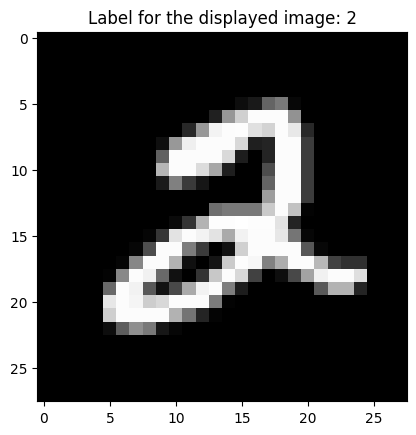

In [23]:
plt.imshow(x_train[5],cmap='gray')
plt.title(f'Label for the displayed image: {y_train[5]}')
plt.show()

In [26]:
model=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128,activation='relu'),
    Dense(64,activation='relu'),
    Dense(10,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [27]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [41]:
history = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9961 - loss: 0.0113 - val_accuracy: 0.9814 - val_loss: 0.0833
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9966 - loss: 0.0107 - val_accuracy: 0.9836 - val_loss: 0.0798
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9970 - loss: 0.0088 - val_accuracy: 0.9814 - val_loss: 0.0847
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9972 - loss: 0.0088 - val_accuracy: 0.9813 - val_loss: 0.0976
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9975 - loss: 0.0079 - val_accuracy: 0.9822 - val_loss: 0.0808
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9977 - loss: 0.0067 - val_accuracy: 0.9834 - val_loss: 0.0898
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9969 - loss: 0.0103 - val_accuracy: 0.9768 - val_loss: 0.1348
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9976 - loss: 0.0072 -

In [34]:
#make Prediction
y_pred=model.predict(x_test)
y_pred=np.argmax(y_pred,axis=1)
print(y_prad)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[7 2 1 ... 4 5 6]


In [31]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f'\nTest accuracy: {test_acc}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9802 - loss: 0.1042

Test accuracy: 0.9801999926567078


In [37]:
print("predicted digits", y_pred)
print("actual digits", y_test)

predicted digits [7 2 1 ... 4 5 6]
actual digits [7 2 1 ... 4 5 6]


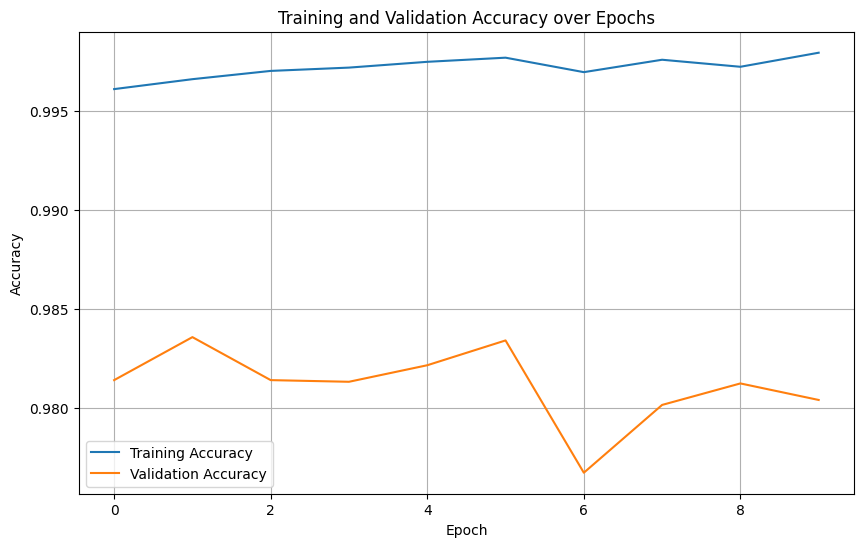

In [42]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()